In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

orders = pd.read_csv('../data/olist_orders_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
revenue = orders.merge(payments, on='order_id')
revenue['year_month'] = revenue['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = revenue.groupby('year_month')['payment_value'].sum().reset_index()

monthly_revenue = monthly_revenue.iloc[1:-2]
monthly_revenue['year_month'] = monthly_revenue['year_month'].dt.to_timestamp()
monthly_revenue = monthly_revenue.set_index('year_month')

print(monthly_revenue.head())
print(f"\nTotal months: {len(monthly_revenue)}")

            payment_value
year_month               
2016-10-01       59090.48
2016-12-01          19.62
2017-01-01      138488.04
2017-02-01      291908.01
2017-03-01      449863.60

Total months: 22


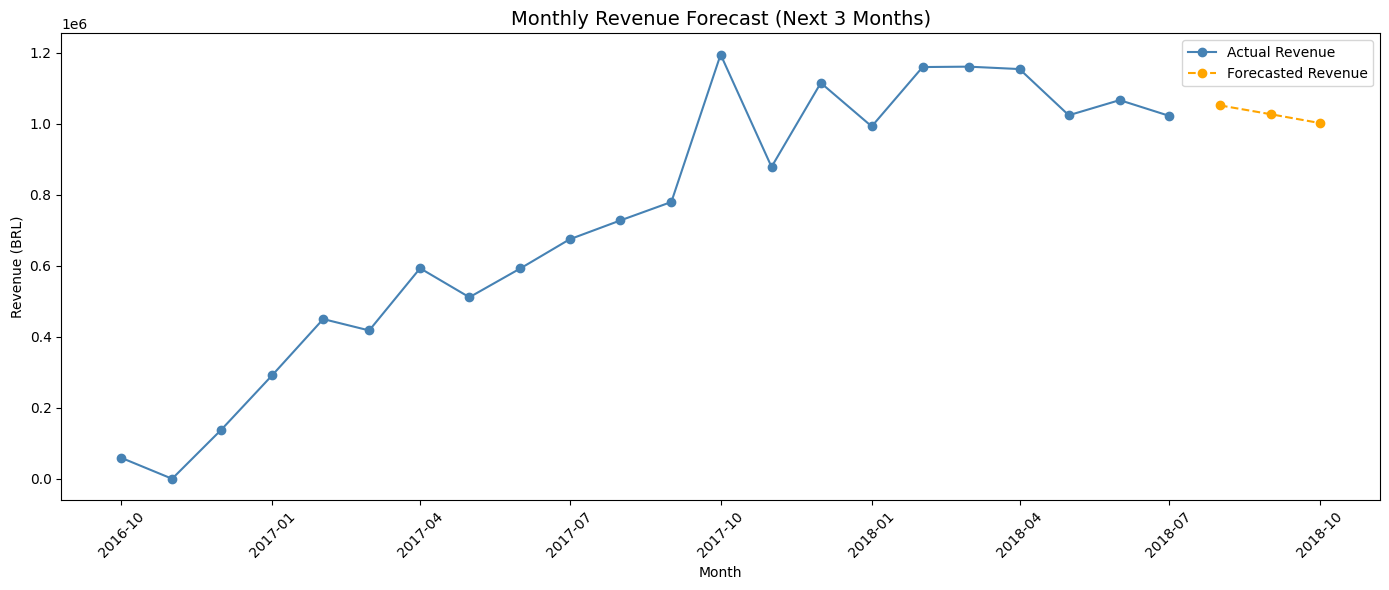


Forecast for next 3 months:
2018-08: 1,051,694.44 BRL
2018-09: 1,026,756.48 BRL
2018-10: 1,001,818.52 BRL


In [4]:
# Fix index frequency
monthly_revenue.index = pd.date_range(start='2016-10', periods=len(monthly_revenue), freq='MS')

# Train model
model = ExponentialSmoothing(
    monthly_revenue['payment_value'],
    trend='add',
    seasonal=None
)
fit = model.fit()

# Forecast next 3 months
forecast = fit.forecast(3)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue.index, monthly_revenue['payment_value'], 
         marker='o', label='Actual Revenue', color='steelblue')
plt.plot(forecast.index, forecast.values, 
         marker='o', label='Forecasted Revenue', color='orange', linestyle='--')
plt.title('Monthly Revenue Forecast (Next 3 Months)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nForecast for next 3 months:")
for date, value in zip(forecast.index, forecast.values):
    print(f"{date.strftime('%Y-%m')}: {value:,.2f} BRL")

In [7]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Remove near-zero months before calculating MAPE
predicted = fit.fittedvalues
actual = monthly_revenue['payment_value']

# Filter out months with very low revenue
mask = actual > 10000
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

print(f"Model Performance:")
print(f"MAE  (Mean Absolute Error): {mae:,.2f} BRL")
print(f"MAPE (Mean Absolute % Error): {mape:.1f}%")
print(f"\nInterpretation: Model predicts monthly revenue")
print(f"with an average error of {mae:,.0f} BRL ({mape:.1f}%)")

Model Performance:
MAE  (Mean Absolute Error): 95,521.38 BRL
MAPE (Mean Absolute % Error): 15.4%

Interpretation: Model predicts monthly revenue
with an average error of 95,521 BRL (15.4%)


# Revenue Forecasting — Executive Summary

## Model
Holt-Winters Exponential Smoothing trained on 22 months of e-commerce data.

## Results
- Forecasted revenue for next 3 months: ~1.0M BRL/month
- Model accuracy: 15.4% MAPE (Mean Absolute Percentage Error)

## Business Value
- Enables inventory planning 90 days in advance
- Reduces overstock and stockout costs
- Provides data-driven basis for budget allocation

## Key Insight
Revenue stabilized around 1M BRL/month in 2018 after rapid growth in 2017,
suggesting market maturation — ideal time to focus on retention over acquisition.

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
import numpy as np

actual = monthly_revenue['payment_value'].values

# ---- Model 1: Exponential Smoothing (веќе го имаме) ----
es_pred = fit.fittedvalues.values
es_mape = np.mean(np.abs((actual[actual > 10000] - es_pred[actual > 10000]) / actual[actual > 10000])) * 100

# ---- Model 2: ARIMA ----
arima_model = ARIMA(monthly_revenue['payment_value'], order=(1, 1, 1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.fittedvalues.values
mask = actual > 10000
arima_mape = np.mean(np.abs((actual[mask] - arima_pred[mask]) / actual[mask])) * 100

# ---- Model 3: Linear Regression ----
X = np.arange(len(actual)).reshape(-1, 1)
lr_model = LinearRegression()
lr_model.fit(X, actual)
lr_pred = lr_model.predict(X)
lr_mape = np.mean(np.abs((actual[mask] - lr_pred[mask]) / actual[mask])) * 100

# ---- Compare ----
results = {
    'Exponential Smoothing': es_mape,
    'ARIMA': arima_mape,
    'Linear Regression': lr_mape
}

print("Model Comparison (MAPE - lower is better):")
print("-" * 40)
for model, mape in sorted(results.items(), key=lambda x: x[1]):
    print(f"{model:25s}: {mape:.1f}%")

best_model = min(results, key=results.get)
print(f"\nBest model: {best_model}")

Model Comparison (MAPE - lower is better):
----------------------------------------
Exponential Smoothing    : 15.4%
Linear Regression        : 21.3%
ARIMA                    : 21.6%

Best model: Exponential Smoothing


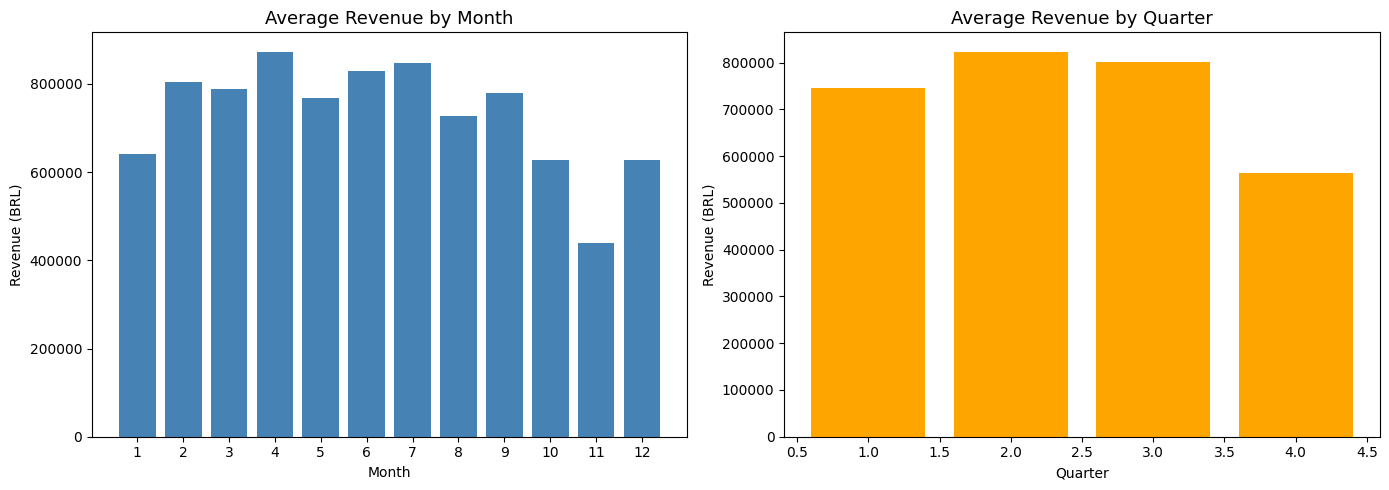


Feature Summary:
      date  month  quarter  is_black_friday  is_q4
2016-10-01     10        4                0      1
2016-11-01     11        4                1      1
2016-12-01     12        4                0      1
2017-01-01      1        1                0      0
2017-02-01      2        1                0      0
2017-03-01      3        1                0      0
2017-04-01      4        2                0      0
2017-05-01      5        2                0      0
2017-06-01      6        2                0      0
2017-07-01      7        3                0      0
2017-08-01      8        3                0      0
2017-09-01      9        3                0      0
2017-10-01     10        4                0      1
2017-11-01     11        4                1      1
2017-12-01     12        4                0      1
2018-01-01      1        1                0      0
2018-02-01      2        1                0      0
2018-03-01      3        1                0      0
2018-04-01   

In [10]:
# Feature Engineering
df = monthly_revenue.copy().reset_index()
df.columns = ['date', 'revenue']

df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['is_black_friday'] = df['month'].apply(lambda x: 1 if x == 11 else 0)
df['is_q4'] = df['quarter'].apply(lambda x: 1 if x == 4 else 0)

# Visualize features impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by month
monthly_avg = df.groupby('month')['revenue'].mean()
axes[0].bar(monthly_avg.index, monthly_avg.values, color='steelblue')
axes[0].set_title('Average Revenue by Month', fontsize=13)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].set_xticks(range(1, 13))

# Revenue by quarter
quarterly_avg = df.groupby('quarter')['revenue'].mean()
axes[1].bar(quarterly_avg.index, quarterly_avg.values, color='orange')
axes[1].set_title('Average Revenue by Quarter', fontsize=13)
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Revenue (BRL)')

plt.tight_layout()
plt.show()

print("\nFeature Summary:")
print(df[['date', 'month', 'quarter', 'is_black_friday', 'is_q4']].to_string(index=False))